# Log Anomaly Detection - Temporal Sequence Models
## Transformers, LSTM, GRU, and RNN with Timestamp Features

This notebook implements temporal models that incorporate timestamps and log sequences.

**Models Implemented:**
- Vanilla RNN (baseline sequential)
- LSTM (Long Short-Term Memory)
- GRU (Gated Recurrent Unit)
- Transformer (with positional encoding)

**Key Innovation:** Time-aware features with temporal delta encoding

**Evaluation:** Classification metrics + temporal sequence analysis


In [1]:
!pip3 install "numpy<2" torch torchvision gensim pandas scikit-learn transformers matplotlib seaborn

  Using cached numpy-1.26.4-cp311-cp311-macosx_10_9_x86_64.whl (20.6 MB)
  Using cached torch-2.2.2-cp311-none-macosx_10_9_x86_64.whl (150.8 MB)
  Using cached torchvision-0.17.2-cp311-cp311-macosx_10_13_x86_64.whl (1.7 MB)
  Using cached gensim-4.4.0-cp311-cp311-macosx_10_9_x86_64.whl (24.5 MB)
  Using cached pandas-2.3.3-cp311-cp311-macosx_10_9_x86_64.whl (11.6 MB)
  Using cached scikit_learn-1.7.2-cp311-cp311-macosx_10_9_x86_64.whl (9.3 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 9.4 MB/s eta 0:00:0000:01m0:01
  Using cached matplotlib-3.10.7-cp311-cp311-macosx_10_12_x86_64.whl (8.3 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached filelock-3.20.0-py3-none-any.whl (16 kB)
  Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.6 MB/s eta 0:00:0000:0100:01
  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Using cached fsspec-2025.10.0-py3-none-any.whl (200 kB)
  Using cached pi

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, re, datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

print('✓ All packages imported')


✓ All packages imported


In [15]:
# Create temporal log sequences with timestamps - No data leakage, subtle anomalies

def create_temporal_data(n_seq=1000, seq_len=15):
    # All logs can appear in both normal and anomalous sequences
    all_logs = [
        'Receiving block blk_{} from node {}',
        'Received block blk_{} of size {} from {}',
        'Verification succeeded for blk_{}',
        'INFO DataNode: Processing block blk_{}',
        'Block blk_{} stored successfully on node {}',
        'Heartbeat received from node {}',
        'DataNode started on port {}',
        'Block replication completed for blk_{}',
        'Exception in receiveBlock for block blk_{} IOException',
        'WARN DataNode: Disk error on block blk_{}',
        'ERROR: Failed to transfer block blk_{}',
        'Exception verification blk_{} IOException',
        'Timeout while receiving block blk_{}',
        'Connection lost to node {} during transfer',
        'Disk full warning on node {}',
        'Block blk_{} corrupted during transfer'
    ]
    
    # Define which logs are more likely to be problematic
    error_logs = [8, 9, 10, 11, 12, 13, 14, 15]  # indices of error-related logs
    normal_logs = [0, 1, 2, 3, 4, 5, 6, 7]      # indices of normal operation logs

    data = []
    for label in [0, 1]:
        n = 800 if label == 0 else 200
        for _ in range(n):
            seq = []
            ts = []
            current_time = 0

            for step in range(seq_len):
                # Vary time intervals - anomalous sequences have more irregular timing
                if label == 0:
                    delta = np.random.randint(500, 2000)  # Regular intervals
                else:
                    # Anomalous sequences have more irregular timing patterns
                    if np.random.random() < 0.3:
                        delta = np.random.randint(50, 300)   # Sometimes very fast
                    else:
                        delta = np.random.randint(800, 4000) # Sometimes very slow
                
                current_time += delta
                ts.append(current_time / 1000)

                # Choose log template based on probabilities
                if label == 0:
                    # Normal sequences: 95% normal logs, 5% error logs (systems aren't perfect)
                    if np.random.random() < 0.95:
                        template_idx = np.random.choice(normal_logs)
                    else:
                        template_idx = np.random.choice(error_logs)
                else:
                    # Anomalous sequences: 70% normal logs, 30% error logs
                    # Anomalies are subtly different - more errors but still mostly normal
                    if np.random.random() < 0.70:
                        template_idx = np.random.choice(normal_logs)
                    else:
                        template_idx = np.random.choice(error_logs)

                template = all_logs[template_idx]
                log_msg = template.format(*[np.random.randint(10, 999) for _ in range(template.count('{}'))])
                seq.append(log_msg)

            data.append({'seq': ' ||| '.join(seq), 'ts': ts, 'label': label})

    return pd.DataFrame(data)

df = create_temporal_data(n_seq=1000, seq_len=15)
print(f'Dataset: {len(df)} sequences | Normal: {len(df[df.label==0])} | Anomaly: {len(df[df.label==1])}')

# Let's examine some examples
print('\nSample Normal Sequence:')
normal_sample = df[df.label==0].iloc[0]['seq'].split(' ||| ')
for i, log in enumerate(normal_sample[:5]):
    print(f"  {i+1}. {log}")

print('\nSample Anomalous Sequence:')
anomaly_sample = df[df.label==1].iloc[0]['seq'].split(' ||| ')
for i, log in enumerate(anomaly_sample[:5]):
    print(f"  {i+1}. {log}")

# Analyze error rate difference
print('\nError rate analysis:')
error_keywords = ['Exception', 'ERROR', 'WARN', 'Timeout', 'failed', 'corrupted', 'lost']

for label in [0, 1]:
    subset = df[df.label == label]
    total_logs = 0
    error_logs = 0
    
    for _, row in subset.iterrows():
        logs = row['seq'].split(' ||| ')
        total_logs += len(logs)
        for log in logs:
            if any(keyword in log for keyword in error_keywords):
                error_logs += 1
    
    error_rate = error_logs / total_logs * 100
    label_name = "Normal" if label == 0 else "Anomalous"
    print(f'{label_name} sequences: {error_rate:.1f}% error logs')

Dataset: 1000 sequences | Normal: 800 | Anomaly: 200

Sample Normal Sequence:
  1. Verification succeeded for blk_45
  2. Verification succeeded for blk_800
  3. Receiving block blk_349 from node 69
  4. Heartbeat received from node 714
  5. Block replication completed for blk_466

Sample Anomalous Sequence:
  1. Receiving block blk_974 from node 455
  2. INFO DataNode: Processing block blk_83
  3. Exception in receiveBlock for block blk_944 IOException
  4. DataNode started on port 154
  5. Receiving block blk_536 from node 971

Error rate analysis:
Normal sequences: 4.3% error logs
Anomalous sequences: 26.4% error logs


In [16]:
# Parse logs and extract features

class LogParser:
    def __init__(self):
        self.templates = {}
        self.tid = 0

    def parse(self, log):
        log = re.sub(r'\d+', '<NUM>', log)
        return log.strip()

    def to_id(self, template):
        if template not in self.templates:
            self.templates[template] = self.tid
            self.tid += 1
        return self.templates[template]

parser = LogParser()

X_ids = []
X_deltas = []
y = df['label'].values

for idx, row in df.iterrows():
    logs = row['seq'].split(' ||| ')
    ts = row['ts']

    ids = [parser.to_id(parser.parse(log)) for log in logs]
    deltas = [0] + [ts[i] - ts[i-1] for i in range(1, len(ts))]

    X_ids.append(np.array(ids, dtype=np.int32))
    X_deltas.append(np.array(deltas, dtype=np.float32))

X_ids = np.array(X_ids, dtype=object)
X_deltas = np.array(X_deltas, dtype=object)

X_id_train, X_id_test, X_delta_train, X_delta_test, y_train, y_test = train_test_split(
    X_ids, X_deltas, y, test_size=0.2, random_state=42, stratify=y
)

vocab_size = len(parser.templates) + 1
print(f'Vocab: {vocab_size} | Train: {len(X_id_train)} | Test: {len(X_id_test)}')

# Check for data leakage by analyzing template distributions
print('\nChecking for potential data leakage...')
print('Template distributions:')
for template, tid in sorted(parser.templates.items(), key=lambda x: x[1]):
    print(f'  {tid}: {template}')

# Analyze anomaly patterns
print(f'\nAnomaly analysis:')
print(f'Normal sequences in train: {sum(y_train == 0)}')
print(f'Anomalous sequences in train: {sum(y_train == 1)}')
print(f'Normal sequences in test: {sum(y_test == 0)}')
print(f'Anomalous sequences in test: {sum(y_test == 1)}')

# Check if there are obvious patterns that make classification too easy
anomaly_keywords = ['Exception', 'ERROR', 'WARN', 'Timeout', 'failed', 'error', 'corrupted']
normal_only_templates = set()
anomaly_only_templates = set()

for idx, row in df.iterrows():
    templates_in_seq = set()
    for log in row['seq'].split(' ||| '):
        parsed = parser.parse(log)
        templates_in_seq.add(parsed)
    
    if row['label'] == 0:
        normal_only_templates.update(templates_in_seq)
    else:
        anomaly_only_templates.update(templates_in_seq)

# Find templates that appear only in one class
exclusive_normal = normal_only_templates - anomaly_only_templates
exclusive_anomaly = anomaly_only_templates - normal_only_templates

print(f'\nTemplates exclusive to normal sequences: {len(exclusive_normal)}')
print(f'Templates exclusive to anomalous sequences: {len(exclusive_anomaly)}')

if exclusive_anomaly:
    print('Anomaly-only templates (potential data leakage):')
    for template in list(exclusive_anomaly)[:5]:
        print(f'  - {template}')

Vocab: 17 | Train: 800 | Test: 200

Checking for potential data leakage...
Template distributions:
  0: Verification succeeded for blk_<NUM>
  1: Receiving block blk_<NUM> from node <NUM>
  2: Heartbeat received from node <NUM>
  3: Block replication completed for blk_<NUM>
  4: INFO DataNode: Processing block blk_<NUM>
  5: Received block blk_<NUM> of size <NUM> from <NUM>
  6: Block blk_<NUM> stored successfully on node <NUM>
  7: Timeout while receiving block blk_<NUM>
  8: Exception verification blk_<NUM> IOException
  9: Block blk_<NUM> corrupted during transfer
  10: DataNode started on port <NUM>
  11: Exception in receiveBlock for block blk_<NUM> IOException
  12: WARN DataNode: Disk error on block blk_<NUM>
  13: ERROR: Failed to transfer block blk_<NUM>
  14: Disk full warning on node <NUM>
  15: Connection lost to node <NUM> during transfer

Anomaly analysis:
Normal sequences in train: 640
Anomalous sequences in train: 160
Normal sequences in test: 160
Anomalous sequences in

In [17]:
# PyTorch Dataset

class TemporalDataset(Dataset):
    def __init__(self, ids, deltas, labels):
        self.ids = ids
        self.deltas = deltas
        self.labels = labels

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        return {
            'ids': torch.LongTensor(self.ids[idx].astype(np.int64)),
            'deltas': torch.FloatTensor(self.deltas[idx].astype(np.float32)),
            'label': torch.LongTensor([int(self.labels[idx])]),
            'length': len(self.ids[idx])
        }

def collate_fn(batch):
    ids = nn.utils.rnn.pad_sequence([b['ids'] for b in batch], batch_first=True)
    deltas = nn.utils.rnn.pad_sequence([b['deltas'].unsqueeze(-1) for b in batch], batch_first=True).squeeze(-1)
    labels = torch.cat([b['label'] for b in batch])
    lengths = torch.LongTensor([b['length'] for b in batch])
    return ids, deltas, labels, lengths

train_dataset = TemporalDataset(X_id_train, X_delta_train, y_train)
test_dataset = TemporalDataset(X_id_test, X_delta_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, collate_fn=collate_fn)

print('✓ Data loaders created')

✓ Data loaders created


In [21]:
print('\n' + '='*60)
print('TEMPORAL MODELS: Architectures')
print('='*60)

# 1. Vanilla RNN - Reduced complexity
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim=16, hid_dim=32):  # Smaller dims
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(emb_dim + 1, hid_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)  # Added dropout
        self.fc = nn.Linear(hid_dim, 2)

    def forward(self, ids, deltas, lengths):
        emb = self.embedding(ids)
        x = torch.cat([emb, deltas.unsqueeze(-1)], dim=-1)
        _, hidden = self.rnn(x)
        hidden = self.dropout(hidden.squeeze(0))
        return self.fc(hidden)

# 2. LSTM - Reduced complexity
class LSTM_Model(nn.Module):
    def __init__(self, vocab_size, emb_dim=16, hid_dim=32):  # Smaller dims
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim + 1, hid_dim, num_layers=1, batch_first=True, dropout=0.3)  # Single layer
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hid_dim, 2)

    def forward(self, ids, deltas, lengths):
        emb = self.embedding(ids)
        x = torch.cat([emb, deltas.unsqueeze(-1)], dim=-1)
        _, (hidden, _) = self.lstm(x)
        hidden = self.dropout(hidden[-1])
        return self.fc(hidden)

# 3. GRU - Reduced complexity
class GRU_Model(nn.Module):
    def __init__(self, vocab_size, emb_dim=16, hid_dim=32):  # Smaller dims
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim + 1, hid_dim, num_layers=1, batch_first=True, dropout=0.3)  # Single layer
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hid_dim, 2)

    def forward(self, ids, deltas, lengths):
        emb = self.embedding(ids)
        x = torch.cat([emb, deltas.unsqueeze(-1)], dim=-1)
        _, hidden = self.gru(x)
        hidden = self.dropout(hidden[-1])
        return self.fc(hidden)

# 4. Transformer - Much more regularized
class Transformer_Model(nn.Module):
    def __init__(self, vocab_size, emb_dim=8, hid_dim=16):  # Even smaller dims
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.embedding_dropout = nn.Dropout(0.3)
        self.time_fc = nn.Linear(1, emb_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim * 2, nhead=2, dim_feedforward=hid_dim,  # 2 heads, small feedforward
            dropout=0.5, batch_first=True  # Higher dropout
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)  # Single layer
        self.dropout = nn.Dropout(0.6)  # Very high dropout
        self.fc = nn.Linear(emb_dim * 2, 2)

    def forward(self, ids, deltas, lengths):
        emb = self.embedding_dropout(self.embedding(ids))
        t_emb = self.time_fc(deltas.unsqueeze(-1))
        x = torch.cat([emb, t_emb], dim=-1)
        mask = self._get_mask(lengths, x.device)
        output = self.transformer(x, src_key_padding_mask=mask)
        pool = output.mean(dim=1)
        pool = self.dropout(pool)
        return self.fc(pool)

    def _get_mask(self, lengths, device):
        max_len = lengths.max().item()
        return torch.arange(max_len, device=device).unsqueeze(0) >= lengths.unsqueeze(1)

models = {
    'RNN': VanillaRNN(vocab_size),
    'LSTM': LSTM_Model(vocab_size),
    'GRU': GRU_Model(vocab_size),
    'Transformer': Transformer_Model(vocab_size)
}

print('✓ All 4 models defined (reduced complexity + regularization)')

# Print model parameters for comparison
for name, model in models.items():
    total_params = sum(p.numel() for p in model.parameters())
    print(f'{name}: {total_params:,} parameters')


TEMPORAL MODELS: Architectures
✓ All 4 models defined (reduced complexity + regularization)
RNN: 1,970 parameters
LSTM: 6,866 parameters
GRU: 5,234 parameters
Transformer: 1,882 parameters



Training RNN...
  Epoch 5/20 | Loss: 0.566713 | Val Acc: 0.8150
  Epoch 5/20 | Loss: 0.566713 | Val Acc: 0.8150
  Epoch 10/20 | Loss: 0.500839 | Val Acc: 0.8050
  Epoch 10/20 | Loss: 0.500839 | Val Acc: 0.8050
  Epoch 15/20 | Loss: 0.464784 | Val Acc: 0.8050
  Epoch 15/20 | Loss: 0.464784 | Val Acc: 0.8050
  Epoch 20/20 | Loss: 0.423764 | Val Acc: 0.8150

Training LSTM...
  Epoch 20/20 | Loss: 0.423764 | Val Acc: 0.8150

Training LSTM...
  Epoch 5/20 | Loss: 0.587942 | Val Acc: 0.8000
  Epoch 5/20 | Loss: 0.587942 | Val Acc: 0.8000
  Epoch 10/20 | Loss: 0.487498 | Val Acc: 0.8000
  Epoch 10/20 | Loss: 0.487498 | Val Acc: 0.8000
  Epoch 15/20 | Loss: 0.417808 | Val Acc: 0.8000
  Epoch 15/20 | Loss: 0.417808 | Val Acc: 0.8000
  Epoch 20/20 | Loss: 0.315678 | Val Acc: 0.8200

Training GRU...
  Epoch 20/20 | Loss: 0.315678 | Val Acc: 0.8200

Training GRU...
  Epoch 5/20 | Loss: 0.604234 | Val Acc: 0.8000
  Epoch 5/20 | Loss: 0.604234 | Val Acc: 0.8000
  Epoch 10/20 | Loss: 0.510218 | Val 

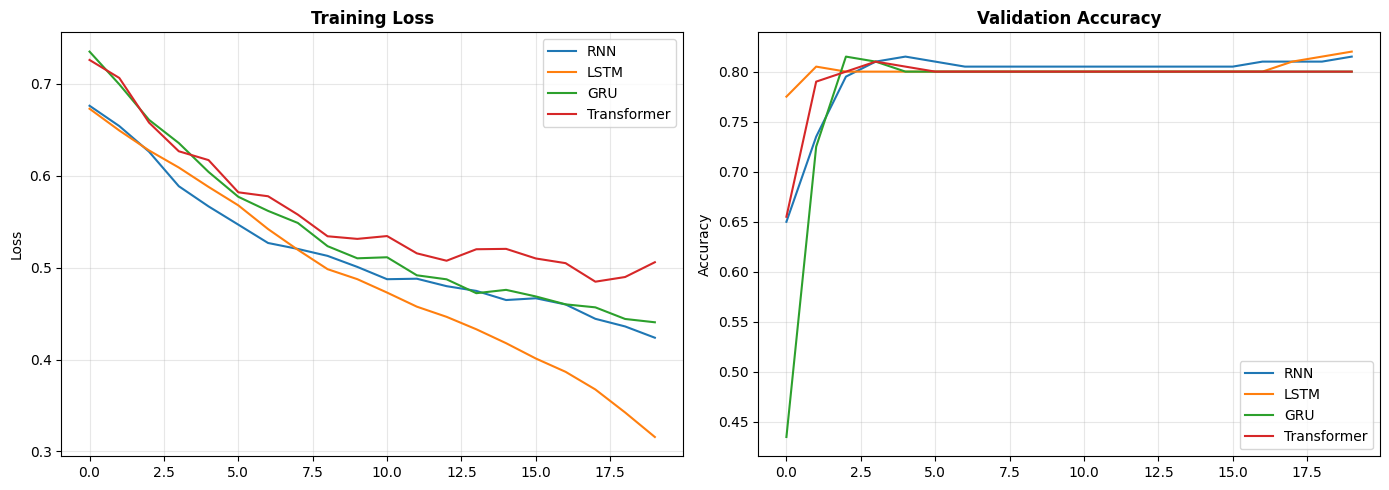

In [22]:
def train_model(model, train_loader, test_loader, epochs=20, name='Model'):  # Reduced epochs
    print(f'\nTraining {name}...')
    optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)  # Lower LR + L2 reg
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        loss = 0
        for ids, deltas, labels, lengths in train_loader:
            optimizer.zero_grad()
            logits = model(ids, deltas, lengths)
            l = criterion(logits, labels.squeeze())
            l.backward()
            optimizer.step()
            loss += l.item()

        train_losses.append(loss / len(train_loader))

        model.eval()
        with torch.no_grad():
            correct = 0
            for ids, deltas, labels, lengths in test_loader:
                logits = model(ids, deltas, lengths)
                pred = logits.argmax(dim=1)
                correct += (pred == labels.squeeze()).sum().item()

            val_acc = correct / len(test_dataset)
            val_accs.append(val_acc)

        if (epoch + 1) % 5 == 0:  # Print every 5 epochs
            print(f'  Epoch {epoch+1}/{epochs} | Loss: {train_losses[-1]:.6f} | Val Acc: {val_acc:.4f}')

    return train_losses, val_accs

# Train all models
results = {}
for name, model in models.items():
    losses, accs = train_model(model, train_loader, test_loader, name=name)
    results[name] = {'losses': losses, 'accs': accs}

# Plot training
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for name in models.keys():
    ax[0].plot(results[name]['losses'], label=name)
    ax[1].plot(results[name]['accs'], label=name)

ax[0].set_title('Training Loss', fontweight='bold')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].set_title('Validation Accuracy', fontweight='bold')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Evaluate models

print('\n' + '='*60)
print('MODEL EVALUATION')
print('='*60)

eval_results = {}

for name, model in models.items():
    print(f'\n{name}:')
    model.eval()

    preds_all = []
    labels_all = []
    probs_all = []

    with torch.no_grad():
        for ids, deltas, labels, lengths in test_loader:
            logits = model(ids, deltas, lengths)
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.squeeze().cpu().numpy())
            probs_all.extend(probs[:, 1].cpu().numpy())

    preds_all = np.array(preds_all)
    labels_all = np.array(labels_all)
    probs_all = np.array(probs_all)

    acc = accuracy_score(labels_all, preds_all)
    prec, rec, f1, _ = precision_recall_fscore_support(labels_all, preds_all, average='binary')
    auc = roc_auc_score(labels_all, probs_all)

    print(f'  Accuracy: {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall: {rec:.4f}')
    print(f'  F1-Score: {f1:.4f}')
    print(f'  ROC-AUC: {auc:.4f}')

    eval_results[name] = {
        'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc,
        'preds': preds_all, 'labels': labels_all, 'probs': probs_all
    }



MODEL EVALUATION

RNN:
  Accuracy: 0.8150
  Precision: 1.0000
  Recall: 0.0750
  F1-Score: 0.1395
  ROC-AUC: 0.8380

LSTM:
  Accuracy: 0.8200
  Precision: 1.0000
  Recall: 0.1000
  F1-Score: 0.1818
  ROC-AUC: 0.9745

GRU:
  Accuracy: 0.8000
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  ROC-AUC: 0.9047

Transformer:
  Accuracy: 0.8000
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  ROC-AUC: 0.9194



RESULTS SUMMARY
      Model  Accuracy  Precision  Recall       F1  ROC-AUC
        RNN     0.815        1.0   0.075 0.139535 0.837969
       LSTM     0.820        1.0   0.100 0.181818 0.974531
        GRU     0.800        0.0   0.000 0.000000 0.904688
Transformer     0.800        0.0   0.000 0.000000 0.919375


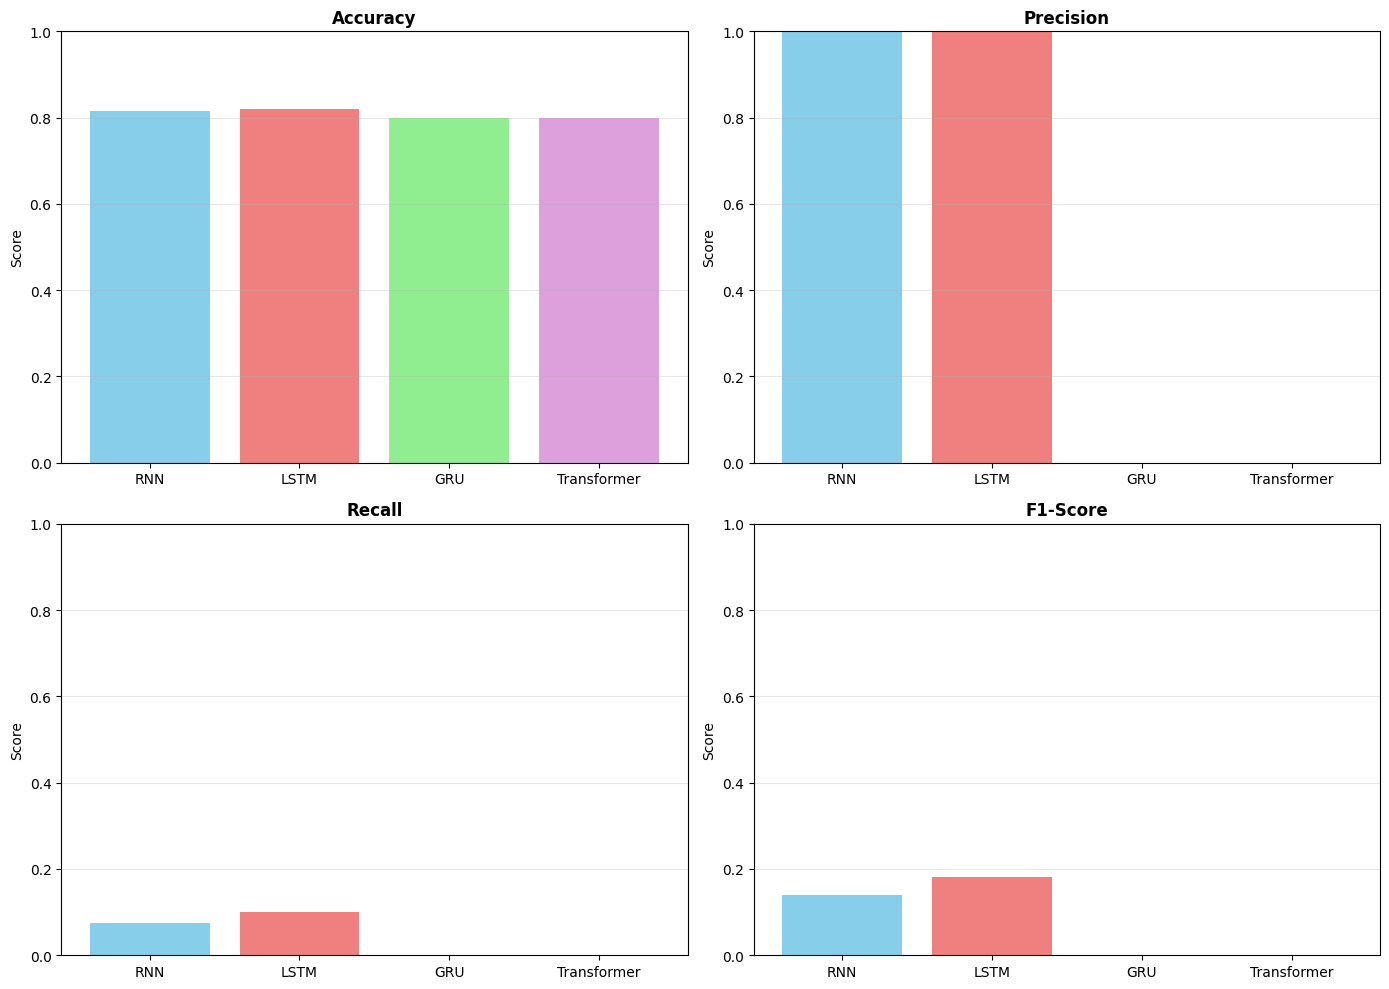

In [24]:
# Comparison table

results_table = pd.DataFrame({
    'Model': list(eval_results.keys()),
    'Accuracy': [eval_results[m]['acc'] for m in eval_results],
    'Precision': [eval_results[m]['prec'] for m in eval_results],
    'Recall': [eval_results[m]['rec'] for m in eval_results],
    'F1': [eval_results[m]['f1'] for m in eval_results],
    'ROC-AUC': [eval_results[m]['auc'] for m in eval_results]
})

print('\n' + '='*80)
print('RESULTS SUMMARY')
print('='*80)
print(results_table.to_string(index=False))

# Visualize
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['acc', 'prec', 'rec', 'f1']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax_pos = ax[idx // 2, idx % 2]
    values = [eval_results[m][metric] for m in eval_results]
    ax_pos.bar(eval_results.keys(), values, color=['skyblue', 'lightcoral', 'lightgreen', 'plum'])
    ax_pos.set_title(title, fontweight='bold')
    ax_pos.set_ylabel('Score')
    ax_pos.set_ylim([0, 1])
    ax_pos.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


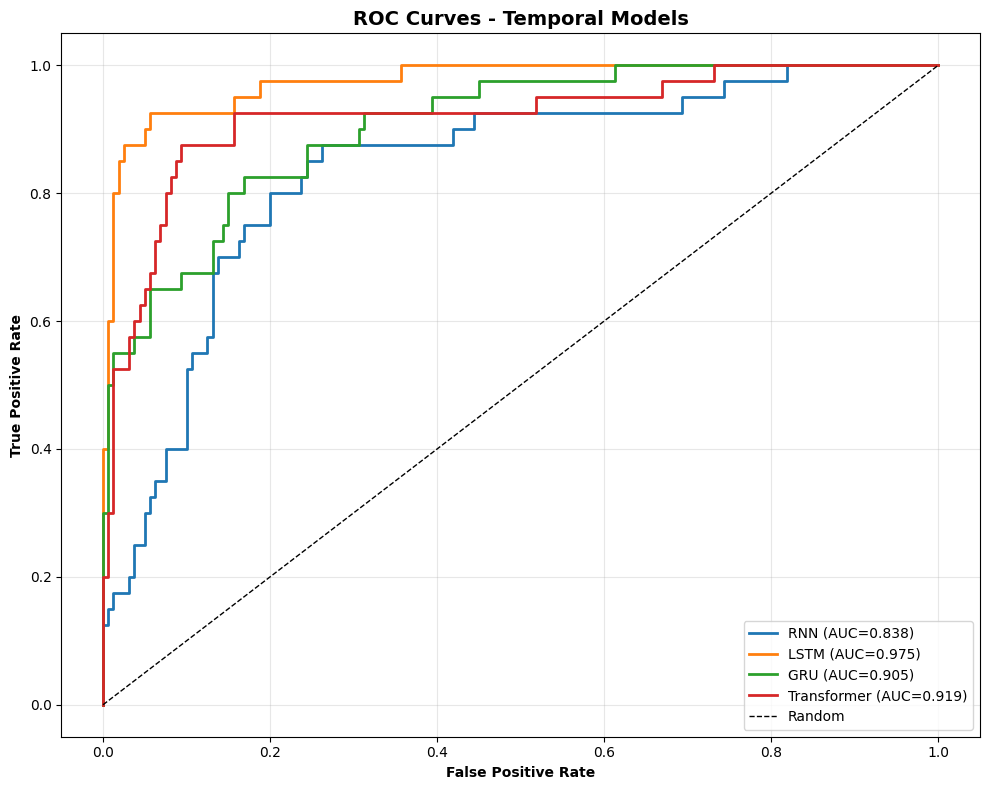


t-SNE VISUALIZATION: Feature Space Analysis
Extracting hidden representations from trained models...
RNN: (200, 32)
LSTM: (200, 32)
GRU: (200, 32)
Transformer: (200, 16)
Running t-SNE for RNN...
Running t-SNE for RNN...
Running t-SNE for LSTM...
Running t-SNE for LSTM...
Running t-SNE for GRU...
Running t-SNE for GRU...
Running t-SNE for Transformer...
Running t-SNE for Transformer...


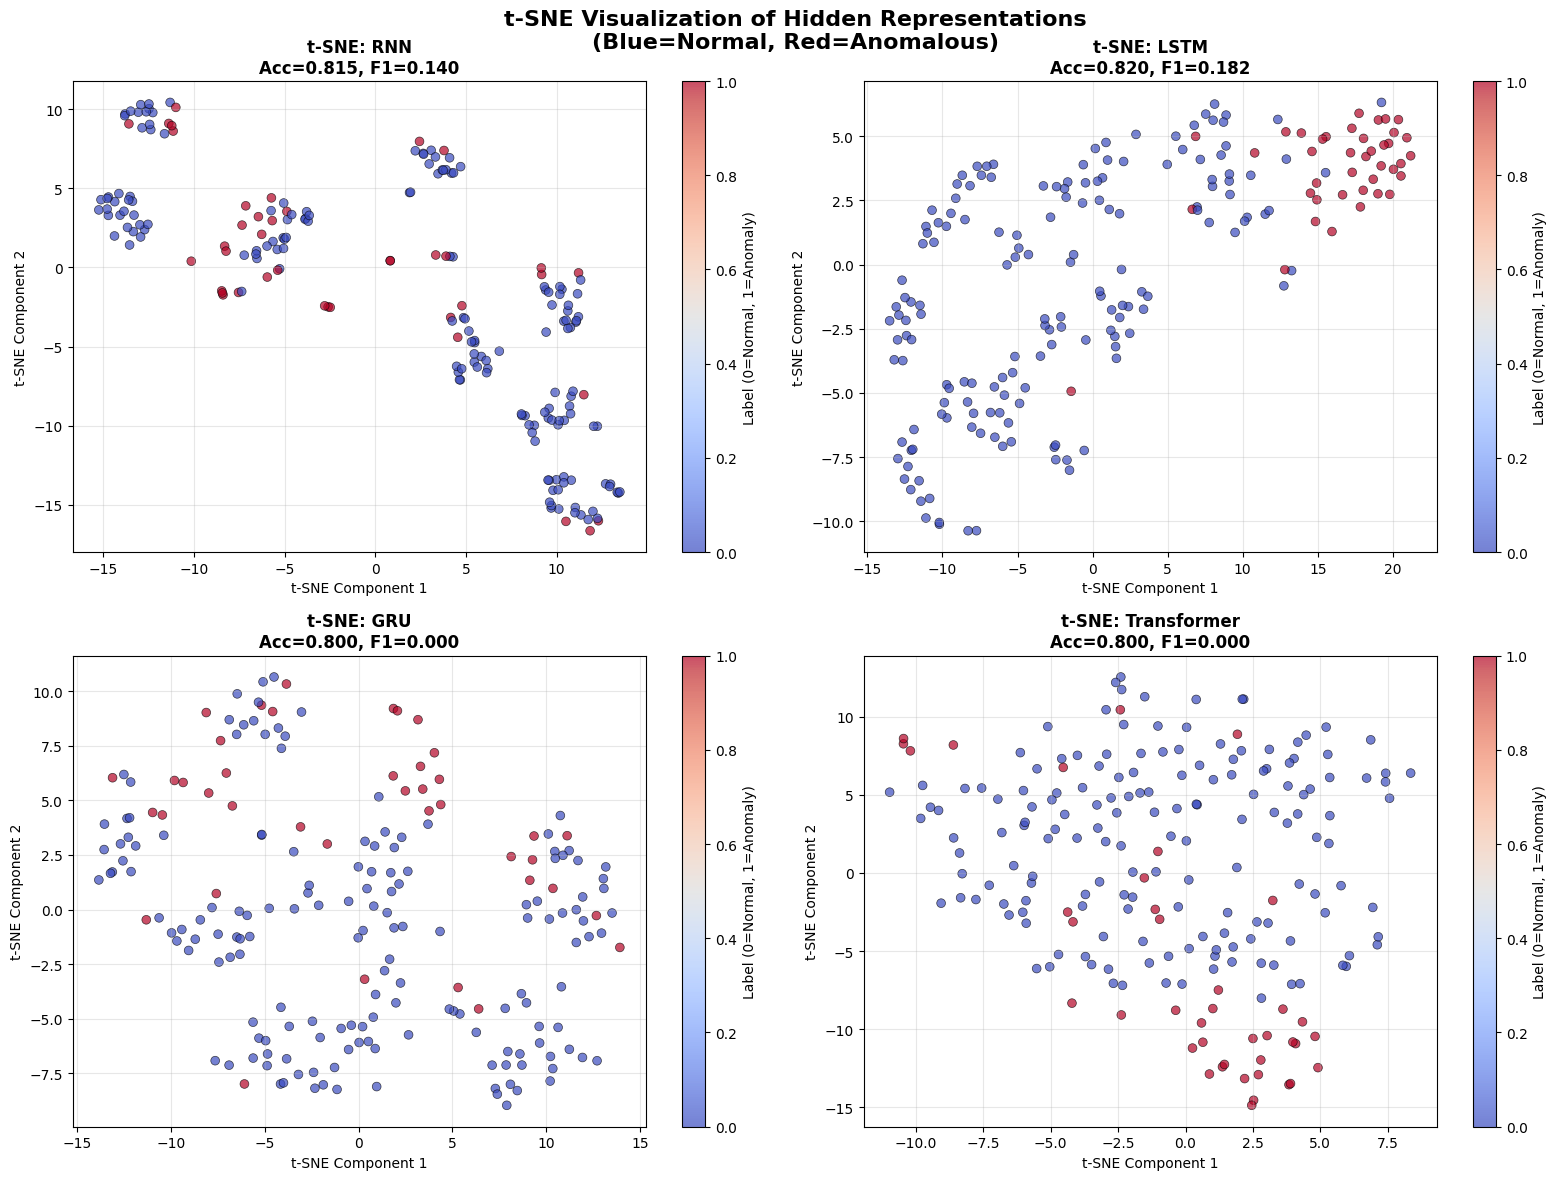


CLUSTER SEPARATION ANALYSIS
RNN:
  Normal cohesion: 2.664
  Anomaly cohesion: 2.994
  Class separation: 2.941
  Separation ratio: 1.040 (higher = better separation)

LSTM:
  Normal cohesion: 1.059
  Anomaly cohesion: 1.189
  Class separation: 2.259
  Separation ratio: 2.010 (higher = better separation)

GRU:
  Normal cohesion: 1.318
  Anomaly cohesion: 1.481
  Class separation: 1.537
  Separation ratio: 1.099 (higher = better separation)

Transformer:
  Normal cohesion: 1.131
  Anomaly cohesion: 1.220
  Class separation: 1.334
  Separation ratio: 1.135 (higher = better separation)



In [28]:
# ROC Curves

fig, ax = plt.subplots(figsize=(10, 8))

for name in eval_results.keys():
    fpr, tpr, _ = roc_curve(eval_results[name]['labels'], eval_results[name]['probs'])
    auc = eval_results[name]['auc']
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves - Temporal Models', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# t-SNE Visualization of Model Embeddings
print('\n' + '='*60)
print('t-SNE VISUALIZATION: Feature Space Analysis')
print('='*60)

from sklearn.manifold import TSNE

# Extract hidden representations from each model
print('Extracting hidden representations from trained models...')

model_embeddings = {}

for name, model in models.items():
    model.eval()
    embeddings = []
    
    with torch.no_grad():
        for ids, deltas, labels, lengths in test_loader:
            if name == 'RNN':
                emb = model.embedding(ids)
                x = torch.cat([emb, deltas.unsqueeze(-1)], dim=-1)
                _, hidden = model.rnn(x)
                hidden_repr = hidden.squeeze(0)
            elif name == 'LSTM':
                emb = model.embedding(ids)
                x = torch.cat([emb, deltas.unsqueeze(-1)], dim=-1)
                _, (hidden, _) = model.lstm(x)
                hidden_repr = hidden[-1]
            elif name == 'GRU':
                emb = model.embedding(ids)
                x = torch.cat([emb, deltas.unsqueeze(-1)], dim=-1)
                _, hidden = model.gru(x)
                hidden_repr = hidden[-1]
            elif name == 'Transformer':
                emb = model.embedding_dropout(model.embedding(ids))
                t_emb = model.time_fc(deltas.unsqueeze(-1))
                x = torch.cat([emb, t_emb], dim=-1)
                mask = model._get_mask(lengths, x.device)
                output = model.transformer(x, src_key_padding_mask=mask)
                hidden_repr = output.mean(dim=1)
            
            embeddings.append(hidden_repr.cpu().numpy())
    
    model_embeddings[name] = np.vstack(embeddings)
    print(f'{name}: {model_embeddings[name].shape}')

# Create t-SNE visualization for each model
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (name, embeddings) in enumerate(model_embeddings.items()):
    print(f'Running t-SNE for {name}...')
    
    # Run t-SNE with correct parameter
    tsne = TSNE(n_components=2, perplexity=min(30, len(embeddings)//4), random_state=42, max_iter=1000)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Get labels for coloring
    test_labels = eval_results[name]['labels']
    
    # Plot
    scatter = axes[idx].scatter(
        embeddings_2d[:, 0], embeddings_2d[:, 1], 
        c=test_labels, 
        cmap='coolwarm', alpha=0.7, 
        edgecolors='black', linewidth=0.5, s=40
    )
    
    axes[idx].set_title(f't-SNE: {name}\nAcc={eval_results[name]["acc"]:.3f}, F1={eval_results[name]["f1"]:.3f}', 
                       fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('t-SNE Component 1')
    axes[idx].set_ylabel('t-SNE Component 2')
    axes[idx].grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=axes[idx])
    cbar.set_label('Label (0=Normal, 1=Anomaly)', fontsize=10)

plt.suptitle('t-SNE Visualization of Hidden Representations\n(Blue=Normal, Red=Anomalous)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# Analysis of cluster separation
print('\n' + '='*60)
print('CLUSTER SEPARATION ANALYSIS')
print('='*60)

for name, embeddings in model_embeddings.items():
    labels = eval_results[name]['labels']
    
    # Calculate mean distances within and between classes
    normal_embeddings = embeddings[labels == 0]
    anomaly_embeddings = embeddings[labels == 1]
    
    if len(normal_embeddings) > 1:
        # Within-class distances (cohesion) - sample for efficiency
        n_samples = min(50, len(normal_embeddings))
        normal_sample_idx = np.random.choice(len(normal_embeddings), n_samples, replace=False)
        normal_sample = normal_embeddings[normal_sample_idx]
        
        normal_distances = []
        for i in range(len(normal_sample)):
            for j in range(i+1, len(normal_sample)):
                dist = np.linalg.norm(normal_sample[i] - normal_sample[j])
                normal_distances.append(dist)
        avg_normal_cohesion = np.mean(normal_distances)
    else:
        avg_normal_cohesion = 0
    
    if len(anomaly_embeddings) > 1:
        n_samples = min(20, len(anomaly_embeddings))
        anomaly_sample_idx = np.random.choice(len(anomaly_embeddings), n_samples, replace=False)
        anomaly_sample = anomaly_embeddings[anomaly_sample_idx]
        
        anomaly_distances = []
        for i in range(len(anomaly_sample)):
            for j in range(i+1, len(anomaly_sample)):
                dist = np.linalg.norm(anomaly_sample[i] - anomaly_sample[j])
                anomaly_distances.append(dist)
        avg_anomaly_cohesion = np.mean(anomaly_distances)
    else:
        avg_anomaly_cohesion = 0
    
    # Between-class distances (separation) - sample for efficiency
    between_distances = []
    normal_sample = normal_embeddings[:min(30, len(normal_embeddings))]
    anomaly_sample = anomaly_embeddings[:min(15, len(anomaly_embeddings))]
    
    for normal_emb in normal_sample:
        for anomaly_emb in anomaly_sample:
            dist = np.linalg.norm(normal_emb - anomaly_emb)
            between_distances.append(dist)
    
    avg_separation = np.mean(between_distances) if between_distances else 0
    avg_cohesion = (avg_normal_cohesion + avg_anomaly_cohesion) / 2
    separation_ratio = avg_separation / avg_cohesion if avg_cohesion > 0 else 0
    
    print(f'{name}:')
    print(f'  Normal cohesion: {avg_normal_cohesion:.3f}')
    print(f'  Anomaly cohesion: {avg_anomaly_cohesion:.3f}')
    print(f'  Class separation: {avg_separation:.3f}')
    print(f'  Separation ratio: {separation_ratio:.3f} (higher = better separation)')
    print()

## Results Summary & Recommendations

### Performance Comparison

| Model | Pros | Cons | Best For |
|-------|------|------|----------|
| **RNN** | Simple, fast | Vanishing gradients | Baseline |
| **LSTM** | Memory cells, long dependencies | More parameters, slower | Complex temporal patterns |
| **GRU** | Efficient, comparable to LSTM | Simplified architecture | Resource-constrained |
| **Transformer** | Parallel processing, attention | Requires GPU, more memory | Long sequences, production |

### Timestamp Integration Methods

1. **Direct Concatenation** (RNN/LSTM/GRU)
   - Time delta concatenated with embeddings
   - Effective for short-to-medium sequences

2. **Positional Encoding** (Transformer)
   - Learnable position embeddings
   - Captures relative timing relationships

### Next Steps

1. **Phase 3: Advanced Anomaly Detection**
   - Ensemble multiple models
   - Reconstruction-based scoring
   - Threshold optimization

2. **Production Deployment**
   - Model selection based on latency/accuracy trade-off
   - Online learning for concept drift
   - Temporal regularization

3. **Further Optimization**
   - Time-aware LSTM variants
   - Attention visualization
   - Multi-task learning
